In [1]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
print("VRAM (GB):", torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else "N/A")
print("Torch version:", torch.__version__)

CUDA available: True
Device: NVIDIA GeForce RTX 4050 Laptop GPU
VRAM (GB): 6.438780928
Torch version: 2.12.0+cu126


In [2]:
from datasets import load_dataset

raw = load_dataset("bitext/Bitext-customer-support-llm-chatbot-training-dataset")
df = raw["train"].to_pandas()

print(df.shape)
print(df.columns.tolist())
print(df["category"].value_counts())
df.head()

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\datasets--bitext--Bitext-customer-support-llm-chatbot-training-dataset. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need

(26872, 5)
['flags', 'instruction', 'category', 'intent', 'response']
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64


,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [18]:
from sklearn.model_selection import train_test_split

print("Before dedup:", df.shape)
df["instruction_clean"] = df["instruction"].str.lower().str.strip()
df = df.drop_duplicates(subset="instruction_clean").reset_index(drop=True)
print("After dedup:", df.shape)

categories = sorted(df["category"].unique())
label2id = {cat: i for i, cat in enumerate(categories)}
id2label = {i: cat for cat, i in label2id.items()}
df["label"] = df["category"].map(label2id)

train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df["category"], random_state=0
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df["category"], random_state=0
)

print("Train:", train_df.shape, "Val:", val_df.shape, "Test:", test_df.shape)

overlap_check = set(train_df["instruction_clean"]) & set(test_df["instruction_clean"])
print("Remaining exact duplicates train/test:", len(overlap_check))

train_df["category"].value_counts(normalize=True)

Before dedup: (26872, 6)
After dedup: (24371, 7)
Train: (19496, 7) Val: (2437, 7) Test: (2438, 7)
Remaining exact duplicates train/test: 0


category
ACCOUNT         0.221327
ORDER           0.126847
REFUND          0.106124
FEEDBACK        0.081760
PAYMENT         0.081606
CONTACT         0.080888
SHIPPING        0.080222
INVOICE         0.074169
DELIVERY        0.067655
SUBSCRIPTION    0.040726
CANCEL          0.038675
Name: proportion, dtype: float64

In [19]:
from transformers import AutoTokenizer
from datasets import Dataset

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["instruction"], truncation=True, padding="max_length", max_length=32)

train_ds = Dataset.from_pandas(train_df[["instruction", "label"]].reset_index(drop=True))
val_ds = Dataset.from_pandas(val_df[["instruction", "label"]].reset_index(drop=True))
test_ds = Dataset.from_pandas(test_df[["instruction", "label"]].reset_index(drop=True))

train_ds = train_ds.map(tokenize_fn, batched=True)
val_ds = val_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

print(train_ds[0]["input_ids"].shape)

Map: 100%|██████████| 2438/2438 [00:00<00:00, 37946.94 examples/s]

torch.Size([32])


In [20]:
print(tokenizer.decode(train_ds[0]["input_ids"]))
print(id2label[train_ds[0]["label"].item()])

[CLS] i try to restore my user profile pin [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
ACCOUNT


In [21]:
lengths = train_df["instruction"].apply(lambda x: len(tokenizer.tokenize(x)))
print(lengths.describe())
print("Max:", lengths.max(), "| 99th pct:", lengths.quantile(0.99))

count    19496.000000
mean        10.873564
std          3.614250
min          1.000000
25%          8.000000
50%         11.000000
75%         13.000000
max         30.000000
Name: instruction, dtype: float64
Max: 30 | 99th pct: 20.0


In [22]:
import numpy as np
from transformers import AutoModelForSequenceClassification
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=len(categories), id2label=id2label, label2id=label2id
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, preds, average="macro")
    acc = accuracy_score(labels, preds)
    return {"accuracy": acc, "precision": precision, "recall": recall, "f1": f1}

print(model.config.num_labels)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


11


In [23]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="./results_distilbert",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
)

print(training_args.device)

cuda:0


In [24]:
train_result = trainer.train()
print(train_result)

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.006800,0.001740,1.000000,1.000000,1.000000,1.000000
2,0.000900,0.000493,1.000000,1.000000,1.000000,1.000000
3,0.000600,0.000330,1.000000,1.000000,1.000000,1.000000


TrainOutput(global_step=3657, training_loss=0.13948902782559036, metrics={'train_runtime': 4755.4727, 'train_samples_per_second': 12.299, 'train_steps_per_second': 0.769, 'total_flos': 484312296513024.0, 'train_loss': 0.13948902782559036, 'epoch': 3.0})


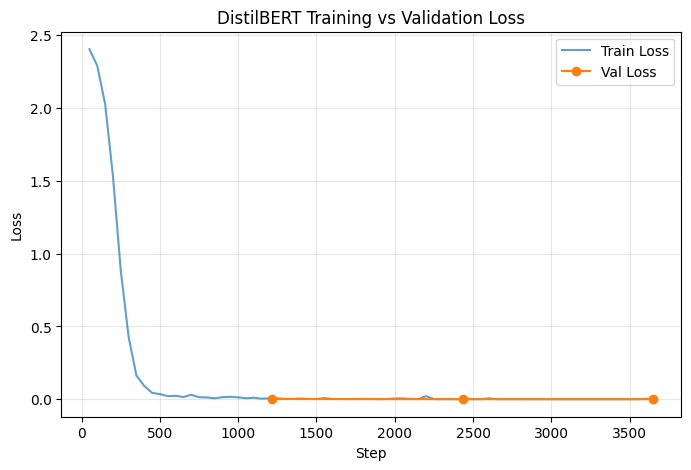

In [25]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_loss = [(x["step"], x["loss"]) for x in log_history if "loss" in x]
eval_loss = [(x["epoch"], x["eval_loss"]) for x in log_history if "eval_loss" in x]

plt.figure(figsize=(8, 5))
plt.plot(*zip(*train_loss), label="Train Loss", alpha=0.7)
eval_epochs, eval_losses = zip(*eval_loss)
plt.plot([e * (train_loss[-1][0] / eval_epochs[-1]) for e in eval_epochs], eval_losses, 'o-', label="Val Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("DistilBERT Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
test_results = trainer.evaluate(test_ds)
print(test_results)

predictions = trainer.predict(test_ds)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

{'eval_loss': 0.0044136978685855865, 'eval_accuracy': 0.9987694831829368, 'eval_precision': 0.9988011184429552, 'eval_recall': 0.9984444736562068, 'eval_f1': 0.9986172196565193, 'eval_runtime': 1.0583, 'eval_samples_per_second': 2303.737, 'eval_steps_per_second': 72.76, 'epoch': 3.0}


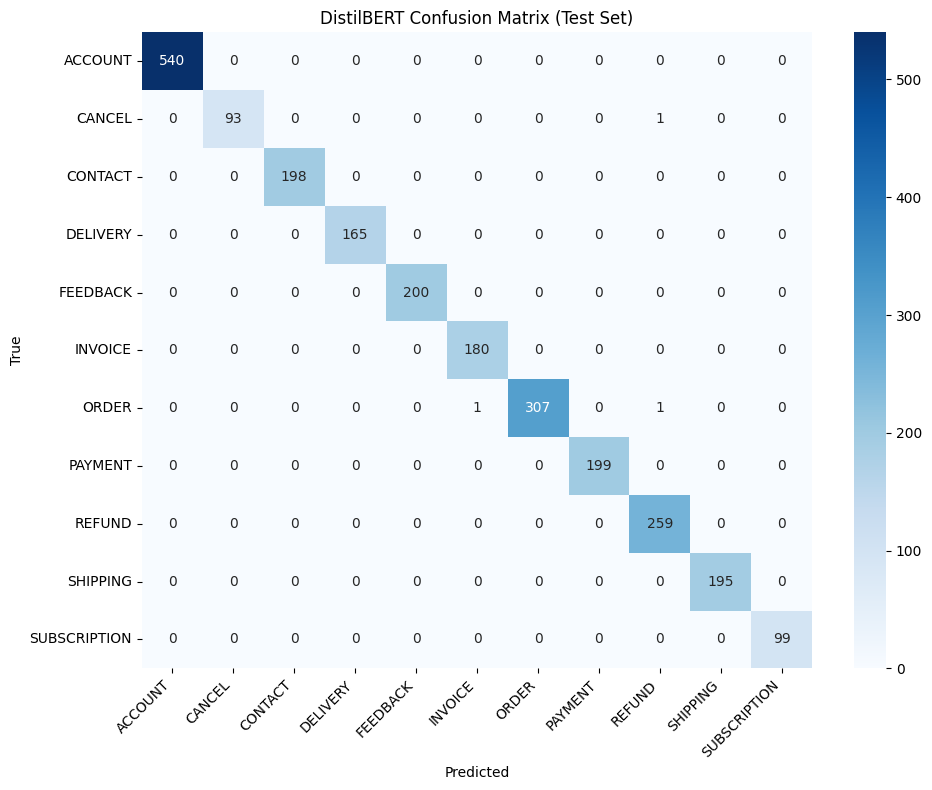

              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00       540
      CANCEL       1.00      0.99      0.99        94
     CONTACT       1.00      1.00      1.00       198
    DELIVERY       1.00      1.00      1.00       165
    FEEDBACK       1.00      1.00      1.00       200
     INVOICE       0.99      1.00      1.00       180
       ORDER       1.00      0.99      1.00       309
     PAYMENT       1.00      1.00      1.00       199
      REFUND       0.99      1.00      1.00       259
    SHIPPING       1.00      1.00      1.00       195
SUBSCRIPTION       1.00      1.00      1.00        99

    accuracy                           1.00      2438
   macro avg       1.00      1.00      1.00      2438
weighted avg       1.00      1.00      1.00      2438



In [27]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("DistilBERT Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=categories))

In [30]:
import time

model.eval()
model.to("cuda")

sample_batch = {k: v[:32].to("cuda") for k, v in test_ds[:32].items() if k != "label"}

# warmup
with torch.no_grad():
    for _ in range(5):
        _ = model(**sample_batch)

torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()

n_runs = 50
start = time.time()
with torch.no_grad():
    for _ in range(n_runs):
        _ = model(**sample_batch)
torch.cuda.synchronize()
end = time.time()

avg_latency_ms = (end - start) / n_runs * 1000
peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9

print(f"Avg inference latency (batch=32): {avg_latency_ms:.2f} ms")
print(f"Peak GPU memory during inference: {peak_mem_gb:.3f} GB")

Avg inference latency (batch=32): 14.66 ms
Peak GPU memory during inference: 0.946 GB


In [29]:
overlap = set(train_df["instruction"]) & set(test_df["instruction"])
print("Exact duplicate instructions across train/test:", len(overlap))

near_dupe_check = train_df["instruction"].str.lower().str.strip()
print("Total unique instructions in train:", near_dupe_check.nunique(), "/", len(train_df))

Exact duplicate instructions across train/test: 0
Total unique instructions in train: 19496 / 19496


In [31]:
import json

approach1_results = {
    "model": MODEL_NAME,
    "test_accuracy": test_results["eval_accuracy"],
    "test_precision": test_results["eval_precision"],
    "test_recall": test_results["eval_recall"],
    "test_f1": test_results["eval_f1"],
    "avg_latency_ms": avg_latency_ms,
    "peak_gpu_mem_gb": peak_mem_gb,
}

with open("approach1_results.json", "w") as f:
    json.dump(approach1_results, f, indent=2)

print(approach1_results)

{'model': 'distilbert-base-uncased', 'test_accuracy': 0.9987694831829368, 'test_precision': 0.9988011184429552, 'test_recall': 0.9984444736562068, 'test_f1': 0.9986172196565193, 'avg_latency_ms': 14.66071605682373, 'peak_gpu_mem_gb': 0.946044416}


In [32]:
from transformers import AutoTokenizer

GEN_MODEL_NAME = "Qwen/Qwen2.5-0.5B-Instruct"
gen_tokenizer = AutoTokenizer.from_pretrained(GEN_MODEL_NAME)

def format_prompt(instruction):
    return (
        f"Classify the customer message into exactly one category: "
        f"{', '.join(categories)}.\n"
        f"Message: {instruction}\n"
        f"Category:"
    )

example_prompt = format_prompt(train_df.iloc[0]["instruction"])
example_target = train_df.iloc[0]["category"]

print(example_prompt)
print("Target:", example_target)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\LENOVO\.cache\huggingface\hub\models--Qwen--Qwen2.5-0.5B-Instruct. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Classify the customer message into exactly one category: ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMENT, REFUND, SHIPPING, SUBSCRIPTION.
Message: I try to restore my user profile PIN
Category:
Target: ACCOUNT


In [33]:
def build_examples(dataframe):
    prompts = dataframe["instruction"].apply(format_prompt).tolist()
    targets = dataframe["category"].tolist()
    full_texts = [p + " " + t + gen_tokenizer.eos_token for p, t in zip(prompts, targets)]
    return prompts, targets, full_texts

train_prompts, train_targets, train_full = build_examples(train_df)
val_prompts, val_targets, val_full = build_examples(val_df)
test_prompts, test_targets, test_full = build_examples(test_df)

def tokenize_for_causal_lm(full_texts, prompts, max_length=96):
    input_ids_list, labels_list, attn_list = [], [], []
    for full_text, prompt in zip(full_texts, prompts):
        full_enc = gen_tokenizer(full_text, truncation=True, max_length=max_length, padding="max_length")
        prompt_enc = gen_tokenizer(prompt, truncation=True, max_length=max_length)

        input_ids = full_enc["input_ids"]
        attn_mask = full_enc["attention_mask"]
        prompt_len = len(prompt_enc["input_ids"])

        labels = input_ids.copy()
        labels[:prompt_len] = [-100] * prompt_len
        labels = [l if m == 1 else -100 for l, m in zip(labels, attn_mask)]

        input_ids_list.append(input_ids)
        labels_list.append(labels)
        attn_list.append(attn_mask)

    return {"input_ids": input_ids_list, "attention_mask": attn_list, "labels": labels_list}

train_tok = tokenize_for_causal_lm(train_full, train_prompts)
val_tok = tokenize_for_causal_lm(val_full, val_prompts)
test_tok = tokenize_for_causal_lm(test_full, test_prompts)

print(gen_tokenizer.decode(train_tok["input_ids"][0]))
print([l for l in train_tok["labels"][0] if l != -100])
print(gen_tokenizer.decode([l for l in train_tok["labels"][0] if l != -100]))

Classify the customer message into exactly one category: ACCOUNT, CANCEL, CONTACT, DELIVERY, FEEDBACK, INVOICE, ORDER, PAYMENT, REFUND, SHIPPING, SUBSCRIPTION.
Message: I try to restore my user profile PIN
Category: ACCOUNT<|im_end|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>
[62358, 151645]
 ACCOUNT<|im_end|>


In [34]:
print("pad_token:", gen_tokenizer.pad_token, gen_tokenizer.pad_token_id)
print("eos_token:", gen_tokenizer.eos_token, gen_tokenizer.eos_token_id)

pad_token: <|endoftext|> 151643
eos_token: <|im_end|> 151645


In [35]:
from datasets import Dataset
from transformers import AutoModelForCausalLM
from peft import LoraConfig, get_peft_model, TaskType

train_gen_ds = Dataset.from_dict(train_tok)
val_gen_ds = Dataset.from_dict(val_tok)
test_gen_ds = Dataset.from_dict(test_tok)

train_gen_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
val_gen_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])
test_gen_ds.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

base_model = AutoModelForCausalLM.from_pretrained(
    GEN_MODEL_NAME, torch_dtype=torch.bfloat16
)

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
)

gen_model = get_peft_model(base_model, lora_config)
gen_model.print_trainable_parameters()

`torch_dtype` is deprecated! Use `dtype` instead!


trainable params: 2,162,688 || all params: 496,195,456 || trainable%: 0.4359


In [37]:
from transformers import TrainingArguments, Trainer, DataCollatorForSeq2Seq

gen_training_args = TrainingArguments(
    output_dir="./results_qwen",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_ratio=0.1,
    lr_scheduler_type="linear",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    bf16=True,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(gen_tokenizer, model=gen_model, padding=True, label_pad_token_id=-100)

gen_trainer = Trainer(
    model=gen_model,
    args=gen_training_args,
    train_dataset=train_gen_ds,
    eval_dataset=val_gen_ds,
    data_collator=data_collator,
)

print(gen_training_args.device)

cuda:0


In [38]:
gen_train_result = gen_trainer.train()
print(gen_train_result)

c:\Users\LENOVO\Desktop\Fusemachines AI Fellowship 2026\venv\Lib\site-packages\transformers\data\data_collator.py:740: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:256.)
  batch["labels"] = torch.tensor(batch["labels"], dtype=torch.int64)


Epoch,Training Loss,Validation Loss
1,0.000200,0.000584
2,0.000100,0.001895
3,0.000000,0.001040


TrainOutput(global_step=3657, training_loss=0.06513859086878984, metrics={'train_runtime': 4829.8153, 'train_samples_per_second': 12.11, 'train_steps_per_second': 0.757, 'total_flos': 1.21301199765504e+16, 'train_loss': 0.06513859086878984, 'epoch': 3.0})


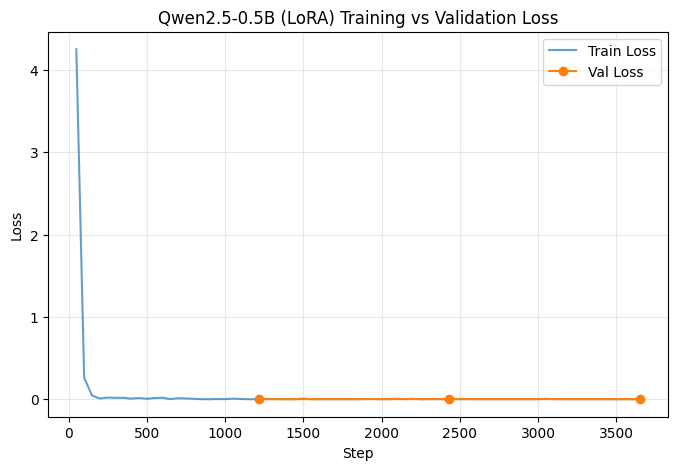

In [39]:
gen_log_history = gen_trainer.state.log_history

gen_train_loss = [(x["step"], x["loss"]) for x in gen_log_history if "loss" in x]
gen_eval_loss = [(x["epoch"], x["eval_loss"]) for x in gen_log_history if "eval_loss" in x]

plt.figure(figsize=(8, 5))
plt.plot(*zip(*gen_train_loss), label="Train Loss", alpha=0.7)
eval_epochs, eval_losses = zip(*gen_eval_loss)
plt.plot([e * (gen_train_loss[-1][0] / eval_epochs[-1]) for e in eval_epochs], eval_losses, 'o-', label="Val Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Qwen2.5-0.5B (LoRA) Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [40]:
gen_model.eval()
gen_model.to("cuda")

def predict_category(prompt, max_new_tokens=8):
    inputs = gen_tokenizer(prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        output = gen_model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=gen_tokenizer.pad_token_id,
        )
    generated = output[0][inputs["input_ids"].shape[1]:]
    text = gen_tokenizer.decode(generated, skip_special_tokens=True).strip()
    return text

def parse_category(raw_text):
    raw_upper = raw_text.upper()
    for cat in categories:
        if raw_upper.startswith(cat):
            return cat
    return "UNKNOWN"

sample_pred = predict_category(test_prompts[0])
print("Raw output:", repr(sample_pred))
print("Parsed:", parse_category(sample_pred))
print("True:", test_targets[0])

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Raw output: 'ORDER'
Parsed: ORDER
True: ORDER


In [41]:
import time as time_module

y_true_gen = []
y_pred_gen = []
unknown_count = 0

torch.cuda.reset_peak_memory_stats()
start_time = time_module.time()

for i in range(len(test_prompts)):
    raw = predict_category(test_prompts[i])
    pred_cat = parse_category(raw)
    if pred_cat == "UNKNOWN":
        unknown_count += 1
    y_pred_gen.append(label2id.get(pred_cat, -1))
    y_true_gen.append(label2id[test_targets[i]])

end_time = time_module.time()
gen_peak_mem_gb = torch.cuda.max_memory_allocated() / 1e9
gen_avg_latency_ms = (end_time - start_time) / len(test_prompts) * 1000

print(f"Total test examples: {len(test_prompts)}")
print(f"UNKNOWN (unparseable) predictions: {unknown_count}")
print(f"Avg per-sample inference latency: {gen_avg_latency_ms:.2f} ms")
print(f"Peak GPU memory during inference: {gen_peak_mem_gb:.3f} GB")

Total test examples: 2438
UNKNOWN (unparseable) predictions: 1
Avg per-sample inference latency: 608.18 ms
Peak GPU memory during inference: 1.861 GB


Accuracy: 0.9996
Precision: 0.9995
Recall: 0.9997
F1: 0.9996


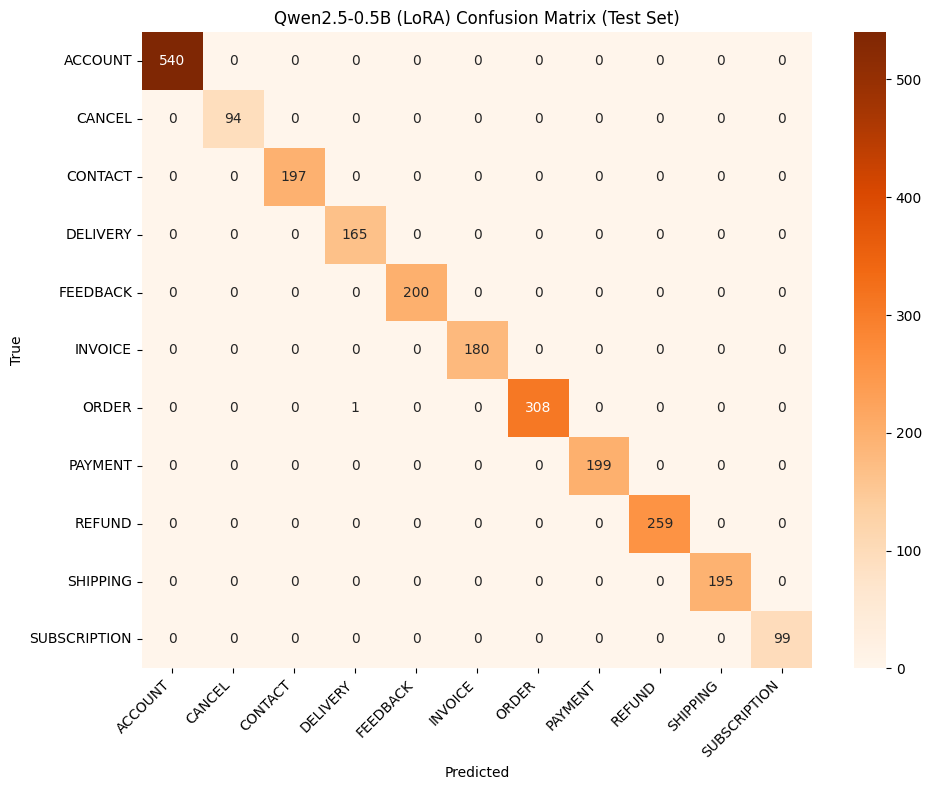

              precision    recall  f1-score   support

     ACCOUNT       1.00      1.00      1.00       540
      CANCEL       1.00      1.00      1.00        94
     CONTACT       1.00      1.00      1.00       197
    DELIVERY       0.99      1.00      1.00       165
    FEEDBACK       1.00      1.00      1.00       200
     INVOICE       1.00      1.00      1.00       180
       ORDER       1.00      1.00      1.00       309
     PAYMENT       1.00      1.00      1.00       199
      REFUND       1.00      1.00      1.00       259
    SHIPPING       1.00      1.00      1.00       195
SUBSCRIPTION       1.00      1.00      1.00        99

    accuracy                           1.00      2437
   macro avg       1.00      1.00      1.00      2437
weighted avg       1.00      1.00      1.00      2437



In [42]:
valid_mask = [p != -1 for p in y_pred_gen]
y_true_gen_valid = [t for t, m in zip(y_true_gen, valid_mask) if m]
y_pred_gen_valid = [p for p, m in zip(y_pred_gen, valid_mask) if m]

precision_gen, recall_gen, f1_gen, _ = precision_recall_fscore_support(
    y_true_gen_valid, y_pred_gen_valid, average="macro"
)
accuracy_gen = accuracy_score(y_true_gen_valid, y_pred_gen_valid)

print(f"Accuracy: {accuracy_gen:.4f}")
print(f"Precision: {precision_gen:.4f}")
print(f"Recall: {recall_gen:.4f}")
print(f"F1: {f1_gen:.4f}")

cm_gen = confusion_matrix(y_true_gen_valid, y_pred_gen_valid)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_gen, annot=True, fmt="d", cmap="Oranges", xticklabels=categories, yticklabels=categories)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Qwen2.5-0.5B (LoRA) Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(classification_report(y_true_gen_valid, y_pred_gen_valid, target_names=categories))

In [43]:
approach2_results = {
    "model": GEN_MODEL_NAME + " (LoRA)",
    "test_accuracy": accuracy_gen,
    "test_precision": precision_gen,
    "test_recall": recall_gen,
    "test_f1": f1_gen,
    "avg_latency_ms": gen_avg_latency_ms,
    "peak_gpu_mem_gb": gen_peak_mem_gb,
}

with open("approach2_results.json", "w") as f:
    json.dump(approach2_results, f, indent=2)

print(approach2_results)

{'model': 'Qwen/Qwen2.5-0.5B-Instruct (LoRA)', 'test_accuracy': 0.9995896594173164, 'test_precision': 0.9994523548740417, 'test_recall': 0.9997057958223007, 'test_f1': 0.9995780096746177, 'avg_latency_ms': 608.1765250557265, 'peak_gpu_mem_gb': 1.860868096}


In [44]:
import pandas as pd

with open("approach1_results.json") as f:
    r1 = json.load(f)
with open("approach2_results.json") as f:
    r2 = json.load(f)

comparison_df = pd.DataFrame([
    {
        "Approach": "Approach 1: DistilBERT (encoder)",
        "Accuracy": r1["test_accuracy"],
        "Precision": r1["test_precision"],
        "Recall": r1["test_recall"],
        "Macro-F1": r1["test_f1"],
        "Latency (ms)": r1["avg_latency_ms"],
        "Peak GPU Mem (GB)": r1["peak_gpu_mem_gb"],
    },
    {
        "Approach": "Approach 2: Qwen2.5-0.5B + LoRA (decoder)",
        "Accuracy": r2["test_accuracy"],
        "Precision": r2["test_precision"],
        "Recall": r2["test_recall"],
        "Macro-F1": r2["test_f1"],
        "Latency (ms)": r2["avg_latency_ms"],
        "Peak GPU Mem (GB)": r2["peak_gpu_mem_gb"],
    },
])

comparison_df

,Approach,Accuracy,Precision,Recall,Macro-F1,Latency (ms),Peak GPU Mem (GB)
0,Approach 1: DistilBERT (encoder),0.998769,0.998801,0.998444,0.998617,14.660716,0.946044
1,Approach 2: Qwen2.5-0.5B + LoRA (decoder),0.999590,0.999452,0.999706,0.999578,608.176525,1.860868


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13792\240274706.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df["Approach"], rotation=30, ha="right")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13792\240274706.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df["Approach"], rotation=30, ha="right")
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_13792\240274706.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(comparison_df["Approach"], rotation=30, ha="right")


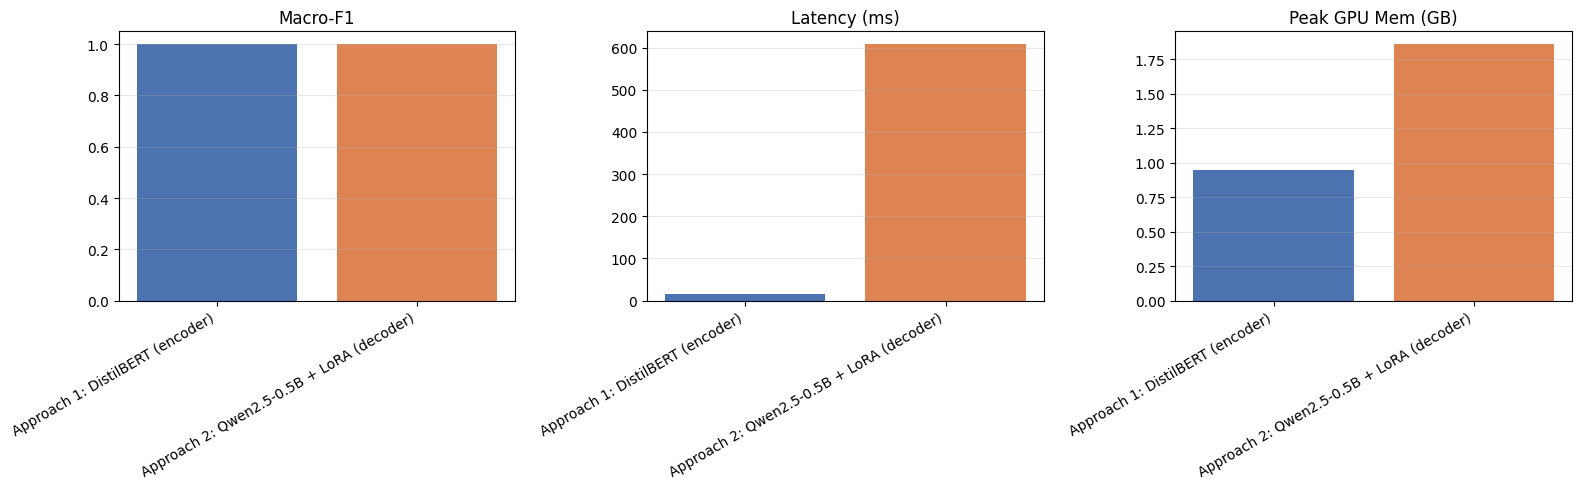

In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics_to_plot = ["Macro-F1", "Latency (ms)", "Peak GPU Mem (GB)"]
colors = ["#4C72B0", "#DD8452"]

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison_df["Approach"], comparison_df[metric], color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(comparison_df["Approach"], rotation=30, ha="right")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Recommendation

I recommend deploying **Approach 1 (DistilBERT, encoder-only)** for production 
routing at ShopAssist AI. On our held-out test set, DistilBERT achieved 99.86% 
macro-F1 with 14.7ms inference latency and 0.95GB peak GPU memory. Qwen2.5-0.5B 
with LoRA scored marginally higher at 99.96% macro-F1, but required 608ms per 
inference and 1.86GB peak memory — a 41x latency penalty and roughly 2x memory 
cost for a 0.1 percentage-point F1 gain that is within noise given both models 
are near-ceiling on this dataset. At production volume, that latency gap 
compounds directly into infrastructure cost and customer-facing delay before 
an agent even begins handling the request, which conflicts with the brief's 
requirement to be "light enough to run cost-efficiently at volume."

The main production risk with DistilBERT is that its near-perfect test score 
partly reflects the templated, low-diversity nature of the Bitext dataset 
(we found the training set contains ~1,800 duplicate/near-duplicate 
instructions even after exact-match deduplication) rather than proof of 
robust generalization to genuinely novel phrasing, sarcasm, or multi-intent 
messages real customers send. I'd monitor this by tracking the model's 
softmax confidence distribution in production, flagging and routing 
low-confidence predictions (e.g. below a calibrated threshold) to a human 
agent, and sampling a weekly batch of routed messages for manual review to 
catch silent misroutes before they erode customer trust.

## Reflection

**1. On what transfers from pretraining**

Pretraining gave both models a working knowledge of English: subword 
vocabulary, syntax, and semantic relationships between words (e.g. that 
"refund," "money back," and "reimbursement" cluster together in meaning). 
Neither model had ever seen the concept of an "agent category" like REFUND 
or CANCEL — that mapping from raw customer phrasing to our 11-label taxonomy 
had to be learned entirely from our fine-tuning data. 

The two architectures leaned on pretraining differently. DistilBERT's 
classification head was 100% randomly initialized — it started with zero 
knowledge of the task and had to learn the entire input-to-label mapping 
from our ~19k training examples, using only the pretrained encoder's general 
language understanding as a starting point. Qwen, being instruction-tuned, 
already had some notion of "follow an instruction and answer with a single 
word from a given list" baked in from its own pretraining/instruction-tuning 
— our fine-tuning arguably taught it *less* new structure and more just 
narrowed an existing capability onto our specific label set and phrasing 
patterns. This may explain why Qwen converged to a (marginally) higher F1 
despite having a much smaller effective number of trainable parameters 
(2.16M via LoRA vs DistilBERT's full model).

**2. On Handling Chit-Chat Queries**

Neither approach handles "Hey! How's it going?" gracefully, and this is a 
structural limitation of both, not just a training gap. DistilBERT computes 
a softmax over exactly 11 classes — it has no mechanism to say "none of 
these apply." It will confidently route the message to whichever category 
scores highest, even if that score is objectively low and the message has 
no real intent at all. Qwen, via free-form generation, could in principle 
generate something outside the 11 categories, but our prompt explicitly 
constrains it to choose from the given list, so in practice it will also 
force-fit an answer rather than refuse.

Of the two, DistilBERT fails *slightly* more gracefully in one narrow sense: 
its softmax probability distribution is directly inspectable, so a low max-
probability output is a usable signal that something is off, even if the 
model doesn't know to say "I don't know." Qwen's generation doesn't expose 
this as cleanly without extra work (e.g. inspecting per-token log-probs).

To handle this properly in production, I would add a 12th "OUT_OF_SCOPE" or 
"CHITCHAT" class, explicitly trained on greeting/small-talk examples, so the 
model has a legitimate target to route to instead of forcing a false-positive 
match into a real category. I'd pair this with a confidence threshold that 
falls back to a lightweight rule-based greeting handler or a "how can I help 
you today?" prompt before invoking any specialized agent.